## Import bibliotek

In [ ]:
import math
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

DATASET_FILE = "rockyou.txt" 


## Definicja klasy MarkovPasswordScorer

In [ ]:
class MarkovPasswordScorer:
    def __init__(self):
        self.transitions = defaultdict(lambda: defaultdict(int))
        self.totals = defaultdict(int)
        self.alphabet = set()
        self.trained = False

    def train(self, filepath):
        if not os.path.exists(filepath):
            print(f"Błąd: Nie znaleziono pliku {filepath}")
            return
        
        print(f"Rozpoczynam trening na: {filepath}")
        
        counter = 0
        
        with open(filepath, 'r', encoding='latin-1', errors='ignore') as f:
            for line in f:
                password = line.strip()
                if not password:
                    continue
                
                # Tokenizacja: ^ = start, $ = koniec
                tokens = ['^'] + list(password) + ['$']
                
                for i in range(len(tokens) - 1):
                    curr, next_char = tokens[i], tokens[i+1]
                    self.transitions[curr][next_char] += 1
                    self.totals[curr] += 1
                    self.alphabet.add(curr)
                    self.alphabet.add(next_char)
                
                counter += 1
                if counter % 1_000_000 == 0:
                    print(f"-> Przetworzono {counter} haseł...")
        
        self.trained = True
        print(f"Trening zakończony! Przetworzono łącznie {counter} haseł.")

    def get_probability(self, char_a, char_b):
        """Oblicza prawdopodobieństwo z wygładzaniem Laplace'a"""
        count = self.transitions[char_a][char_b]
        total = self.totals[char_a]
        vocab_size = len(self.alphabet)
        return (count + 1) / (total + vocab_size)

    def score(self, password):
        """Zwraca wynik jako sumę logarytmów"""
        if not self.trained:
            raise Exception("Model nie jest wytrenowany!")
            
        tokens = ['^'] + list(password) + ['$']
        log_prob_sum = 0.0
        details = []

        for i in range(len(tokens) - 1):
            char_a, char_b = tokens[i], tokens[i+1]
            prob = self.get_probability(char_a, char_b)
            log_prob = math.log10(prob)
            log_prob_sum += log_prob
            details.append((f"{char_a}->{char_b}", prob, log_prob))
            
        return log_prob_sum, details
    

## Uruchomienie Treningu

In [ ]:
model = MarkovPasswordScorer()

model.train(DATASET_FILE)

Rozpoczynam trening na: rockyou.txt
-> Przetworzono 1000000 haseł...
-> Przetworzono 2000000 haseł...
-> Przetworzono 3000000 haseł...
-> Przetworzono 4000000 haseł...
-> Przetworzono 5000000 haseł...
-> Przetworzono 6000000 haseł...
-> Przetworzono 7000000 haseł...
-> Przetworzono 8000000 haseł...
-> Przetworzono 9000000 haseł...
-> Przetworzono 10000000 haseł...
-> Przetworzono 11000000 haseł...
-> Przetworzono 12000000 haseł...
-> Przetworzono 13000000 haseł...
-> Przetworzono 14000000 haseł...
Trening zakończony! Przetworzono łącznie 14344380 haseł.


## Testowanie haseł

In [ ]:

def analyze_passwords(passwords_list):
    results = []
    for pwd in passwords_list:
        score, _ = model.score(pwd)
        score_per_char = score / (len(pwd) + 2) 
        results.append({
            "Hasło": pwd,
            "Wynik (LogProb)": round(score, 2),
            "Wynik na znak": round(score_per_char, 2)
        })
    
    df = pd.DataFrame(results)
    df = df.sort_values(by="Wynik (LogProb)", ascending=False) 
    return df

# Twoja lista do testów
test_list = [
    "admin",
    "123456", 
    "password", 
    "admin1", 
    "kochamcie", 
    "TrudneHaslo!", 
    "Xy9#mZ!pL",
    "bardzodlugiehasloalebezcyfr",
    "qwerty",
]

analyze_passwords(test_list)

,Hasło,Wynik (LogProb),Wynik na znak
1,123456,-7.04,-0.88
0,admin,-7.39,-1.06
3,admin1,-8.54,-1.07
8,qwerty,-9.26,-1.16
2,password,-11.56,-1.16
4,kochamcie,-12.08,-1.10
9,kox#vanisz1,-19.45,-1.50
5,TrudneHaslo!,-22.91,-1.64
6,Xy9#mZ!pL,-28.90,-2.63
7,bardzodlugiehasloalebezcyfr,-39.74,-1.37


## Wizualizacja Macierzy Przejść (Heatmapa)

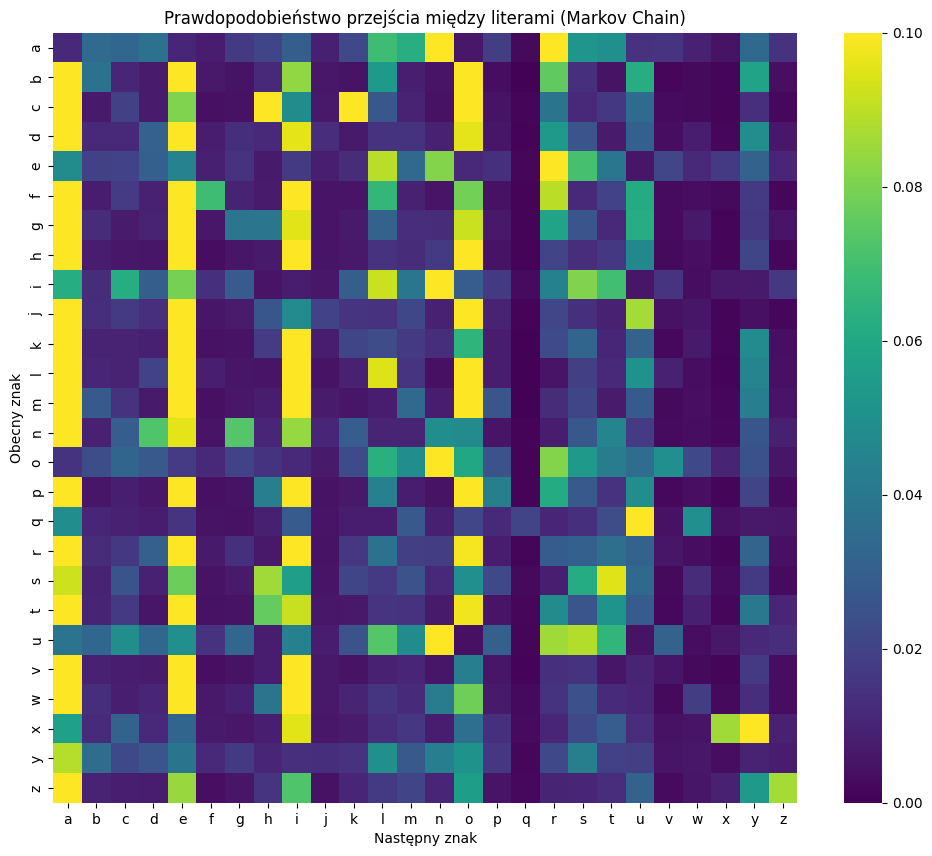

In [8]:
def plot_heatmap(chars_to_show="abcdefghijklmnopqrstuvwxyz"):
    """Rysuje mapę ciepła dla wybranych znaków"""
    matrix = []
    labels = list(chars_to_show)
    
    for row_char in labels:
        row_data = []
        for col_char in labels:
            prob = model.get_probability(row_char, col_char)
            row_data.append(prob)
        matrix.append(row_data)
        
    df_map = pd.DataFrame(matrix, index=labels, columns=labels)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_map, annot=False, cmap="viridis", vmin=0, vmax=0.1)
    plt.title("Prawdopodobieństwo przejścia między literami (Markov Chain)")
    plt.xlabel("Następny znak")
    plt.ylabel("Obecny znak")
    plt.show()

# Rysujemy mapę dla małych liter
plot_heatmap("abcdefghijklmnopqrstuvwxyz")

Debugowanie konkretnego hasła

In [ ]:

target_password = "admin"  

score, details = model.score(target_password)

print(f"Analiza dla: '{target_password}' (Total Score: {score:.4f})")
print("-" * 50)
print(f"{'Przejście':<10} | {'Prawdopodobieństwo':<20} | {'Log10'}")
print("-" * 50)

for step in details:
    trans, prob, log = step
    bar = "#" * int(prob * 50) 
    print(f"{trans:<10} | {prob:.6f} {bar:<15} | {log:.4f}")

Analiza dla: 'admin' (Total Score: -7.3882)
--------------------------------------------------
Przejście  | Prawdopodobieństwo   | Log10
--------------------------------------------------
^->a       | 0.048897 ##              | -1.3107
a->d       | 0.037593 #               | -1.4249
d->m       | 0.014578                 | -1.8363
m->i       | 0.123656 ######          | -0.9078
i->n       | 0.143799 #######         | -0.8422
n->$       | 0.085845 ####            | -1.0663
